<a href="https://colab.research.google.com/github/paul195samudra/Fraud-Detection-In-Bank-Transaction/blob/main/New_dataset_Of_a_bank_in_India_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("/content/drive/MyDrive/indian_banking_transactions.csv")

df.head().round(2)

,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Dataset Shape: (550000, 20)

Column Names:
['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'account_type', 'transaction_type', 'transaction_amount', 'transaction_direction', 'account_balance', 'merchant_category', 'state', 'credit_score', 'has_loan', 'loan_type', 'emi_amount', 'transaction_status', 'channel', 'kyc_status', 'is_fraud', 'transaction_hour']

Data Types:
transaction_id            object
customer_id               object
transaction_date          object
transaction_time          object
account_type              object
transaction_type          object
transaction_amount       float64
transaction_direction     object
account_balance          float64
merchant_category         object
state                     object
credit_score               int64
has_loan                   int64
loan_type                 object
emi_amount               float64
transaction_status        object
channel                   object
kyc_status                object
is_fraud  

,0
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
account_type,0
transaction_type,0
transaction_amount,0
transaction_direction,0
account_balance,0
merchant_category,0


In [6]:
print("Fraud Distribution:")

display(
    df["is_fraud"].value_counts()
)

print("\nFraud Percentage:")

display(
    df["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
)

Fraud Distribution:


,count
is_fraud,
0,545127
1,4873



Fraud Percentage:


,proportion
is_fraud,
0,99.114
1,0.886


In [7]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["transaction_year"] = (df["transaction_date"].dt.year)

df["transaction_month"] = (df["transaction_date"].dt.month)

df["transaction_day"] = (df["transaction_date"].dt.day)

df["transaction_day_of_week"] = (df["transaction_date"].dt.dayofweek)

In [8]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,...,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour,transaction_year,transaction_month,transaction_day,transaction_day_of_week
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,...,0.00,Success,Branch,Verified,0,15,2019,1,1,1
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,...,0.00,Success,Mobile_App,Verified,0,3,2019,1,1,1
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,...,1433.91,Success,Mobile_App,Verified,0,18,2019,1,1,1
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,...,6280.35,Success,API,Verified,0,8,2019,1,1,1
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,...,0.00,Success,API,Verified,0,14,2019,1,1,1


In [9]:
df[
    [
        "transaction_date",
        "transaction_time",
        "transaction_hour",
        "transaction_year",
        "transaction_month",
        "transaction_day",
        "transaction_day_of_week"
    ]
].head()

,transaction_date,transaction_time,transaction_hour,transaction_year,transaction_month,transaction_day,transaction_day_of_week
0,2019-01-01,15:28,15,2019,1,1,1
1,2019-01-01,03:00,3,2019,1,1,1
2,2019-01-01,18:03,18,2019,1,1,1
3,2019-01-01,08:03,8,2019,1,1,1
4,2019-01-01,14:23,14,2019,1,1,1


In [10]:
df_processed = df.copy()

df_processed = df_processed.drop(
    columns=[
        "transaction_id",
        "customer_id",
        "transaction_date",
        "transaction_time"
    ]
)

In [11]:
print(df_processed.shape)
display(df_processed.head())

(550000, 20)


,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour,transaction_year,transaction_month,transaction_day,transaction_day_of_week
0,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15,2019,1,1,1
1,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3,2019,1,1,1
2,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18,2019,1,1,1
3,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8,2019,1,1,1
4,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14,2019,1,1,1


In [12]:
X = df_processed.drop(columns=["is_fraud"])

y = df_processed["is_fraud"]

In [13]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['account_type', 'transaction_type', 'transaction_direction', 'merchant_category', 'state', 'loan_type', 'transaction_status', 'channel', 'kyc_status']

Numerical Columns:
['transaction_amount', 'account_balance', 'credit_score', 'has_loan', 'emi_amount', 'transaction_hour', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_day_of_week']


In [15]:
for column in categorical_columns:X[column] = X[column].fillna("Unknown")
for column in numerical_columns:X[column] = X[column].fillna(X[column].median())

In [16]:
X = pd.get_dummies(X,columns=categorical_columns,drop_first=True)

In [17]:
X = X.astype("float32")

In [19]:
print("Final Feature Shape:",X.shape)

print("\nTarget Shape:", y.shape)

print("\nAny Missing Values:",X.isnull().sum().sum())

display(X.head().round(2))

Final Feature Shape: (550000, 63)

Target Shape: (550000,)

Any Missing Values: 0


,transaction_amount,account_balance,credit_score,has_loan,emi_amount,transaction_hour,transaction_year,transaction_month,transaction_day,transaction_day_of_week,...,transaction_status_Pending,transaction_status_Reversed,transaction_status_Success,channel_ATM,channel_Branch,channel_Mobile_App,channel_POS_Terminal,channel_Web,kyc_status_Pending,kyc_status_Verified
0,1820.170044,609365.312500,764.0,0.0,0.000000,15.0,2019.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,392.670013,14451.139648,630.0,0.0,0.000000,3.0,2019.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1255.969971,47621.871094,813.0,1.0,1433.910034,18.0,2019.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,2580.679932,34467.851562,628.0,1.0,6280.350098,8.0,2019.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2573.800049,26617.400391,767.0,0.0,0.000000,14.0,2019.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [20]:
df_sorted = df.sort_values(by=["transaction_date","transaction_time"]).copy()

In [21]:
df_sorted["transaction_date"] = pd.to_datetime(
    df_sorted["transaction_date"]
)

df_sorted["transaction_year"] = (
    df_sorted["transaction_date"].dt.year
)

df_sorted["transaction_month"] = (
    df_sorted["transaction_date"].dt.month
)

df_sorted["transaction_day"] = (
    df_sorted["transaction_date"].dt.day
)

df_sorted["transaction_day_of_week"] = (
    df_sorted["transaction_date"].dt.dayofweek
)

In [22]:
df_sorted = df_sorted.drop(
    columns=[
        "transaction_id",
        "customer_id",
        "transaction_date",
        "transaction_time"
    ]
)

In [23]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

In [24]:
for column in categorical_columns:

    X[column] = X[column].fillna(
        "Unknown"
    )

for column in numerical_columns:

    X[column] = X[column].fillna(
        X[column].median()
    )

In [25]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X = X.astype(
    "float32"
)

80% oldest transactions → training
20% newest transactions → testing

In [26]:
split_index = int(
    len(X) * 0.8
)

X_train = X.iloc[
    :split_index
].copy()

X_test = X.iloc[
    split_index:
].copy()

y_train = y.iloc[
    :split_index
].copy()

y_test = y.iloc[
    split_index:
].copy()

In [27]:
print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)

print(
    "\nTraining Target Distribution:"
)

display(
    y_train.value_counts()
)

print(
    "\nTesting Target Distribution:"
)

display(
    y_test.value_counts()
)

Training Data: (440000, 63)
Testing Data: (110000, 63)

Training Target Distribution:


,count
is_fraud,
0,436111
1,3889



Testing Target Distribution:


,count
is_fraud,
0,109016
1,984


Apply SMOTE in training data


In [28]:
smote = SMOTE(
    random_state=42
)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [29]:
print("Training Data After SMOTE:")

display(y_train.value_counts())

Training Data After SMOTE:


,count
is_fraud,
0,436111
1,436111


In [30]:
print(
    "Class Ratio After SMOTE:"
)

print(
    y_train.value_counts()
)


Class Ratio After SMOTE:
is_fraud
0    436111
1    436111
Name: count, dtype: int64


In [31]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

In [32]:
xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost training completed successfully."
)

XGBoost training completed successfully.


In [33]:
y_pred = xgb_model.predict(
    X_test
)

y_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

In [34]:
print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_prob
        ),
        4
    )
)

Accuracy: 0.9911
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.537
PR-AUC: 0.0163


In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00    109016
       Fraud       0.00      0.00      0.00       984

    accuracy                           0.99    110000
   macro avg       0.50      0.50      0.50    110000
weighted avg       0.98      0.99      0.99    110000



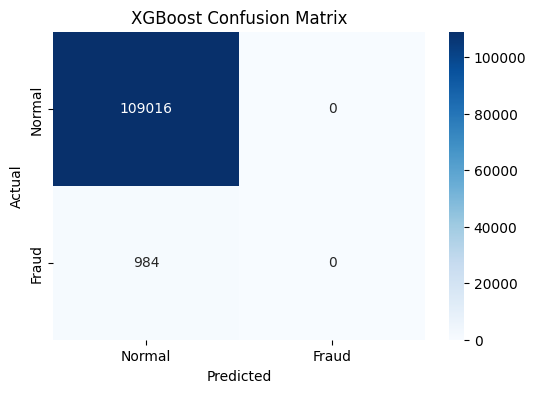

In [36]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(6, 4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "Fraud"
    ],
    yticklabels=[
        "Normal",
        "Fraud"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

In [37]:
feature_importances = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
)

feature_importances = (
    feature_importances
    .sort_values(
        ascending=False
    )
)

display(
    feature_importances.head(20)
)

,0
channel_Mobile_App,0.097931
transaction_year,0.090735
account_type_Savings,0.072875
state_Maharashtra,0.056976
transaction_direction_Debit,0.054234
transaction_type_UPI,0.051403
channel_Web,0.049060
account_type_Salary,0.048396
channel_ATM,0.040178
state_Karnataka,0.033865


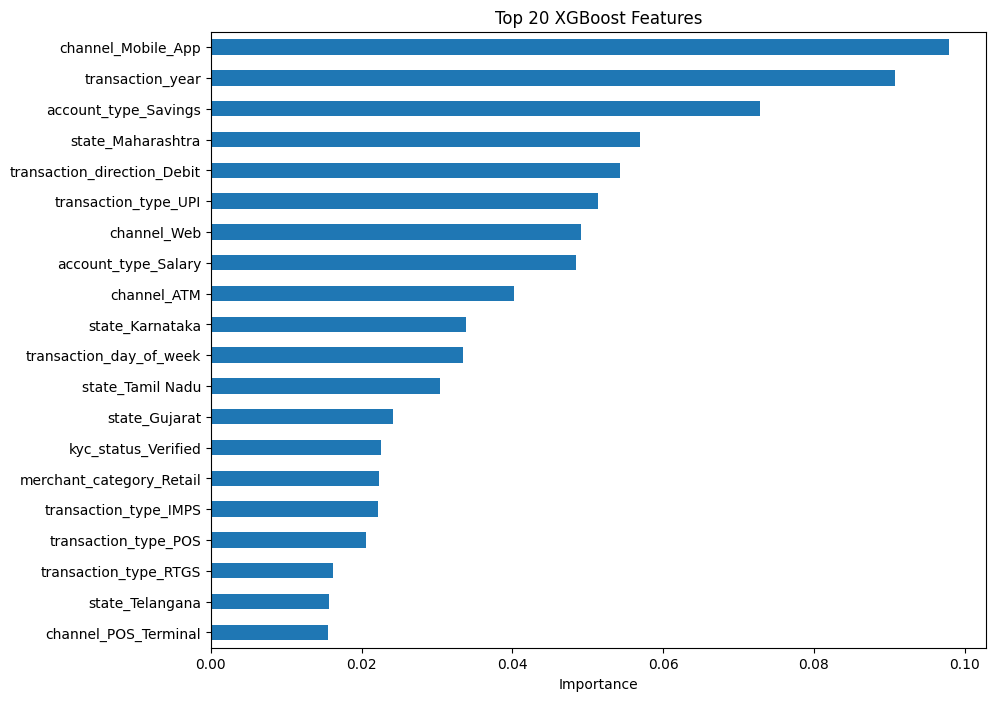

In [38]:
plt.figure(
    figsize=(10, 8)
)

feature_importances.head(
    20
).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 XGBoost Features"
)

plt.xlabel(
    "Importance"
)

plt.show()

In [39]:
results = X_test.copy()

results["actual_fraud"] = y_test.values

results["predicted_fraud"] = y_pred

results["fraud_probability"] = y_prob

display(
    results.head()
)

,transaction_amount,account_balance,credit_score,has_loan,emi_amount,transaction_hour,transaction_year,transaction_month,transaction_day,transaction_day_of_week,...,channel_ATM,channel_Branch,channel_Mobile_App,channel_POS_Terminal,channel_Web,kyc_status_Pending,kyc_status_Verified,actual_fraud,predicted_fraud,fraud_probability
440000,20230.900391,106561.468750,729.0,0.0,0.000000,15.0,2022.0,12.0,31.0,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,0.009465
440001,1069.550049,78284.421875,365.0,0.0,0.000000,5.0,2022.0,12.0,31.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0.005607
440002,1141.729980,319881.093750,380.0,1.0,7653.359863,15.0,2022.0,12.0,31.0,5.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.007332
440003,8210.480469,17616.349609,854.0,0.0,0.000000,20.0,2022.0,12.0,31.0,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,0.010279
440004,935.380005,26339.929688,527.0,1.0,3212.969971,14.0,2022.0,12.0,31.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,0,0.010919


# New Approach  **Random Forest**

In [42]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_csv('/content/drive/MyDrive/indian_banking_transactions.csv')

print(f" Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head()

 Dataset Shape: 550,000 rows × 20 columns



,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550000 entries, 0 to 549999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_id         550000 non-null  object 
 1   customer_id            550000 non-null  object 
 2   transaction_date       550000 non-null  object 
 3   transaction_time       550000 non-null  object 
 4   account_type           550000 non-null  object 
 5   transaction_type       550000 non-null  object 
 6   transaction_amount     550000 non-null  float64
 7   transaction_direction  550000 non-null  object 
 8   account_balance        550000 non-null  float64
 9   merchant_category      550000 non-null  object 
 10  state                  550000 non-null  object 
 11  credit_score           550000 non-null  int64  
 12  has_loan               550000 non-null  int64  
 13  loan_type              172866 non-null  object 
 14  emi_amount             550000 non-nu

In [45]:
df.describe().round(2)

,transaction_amount,account_balance,credit_score,has_loan,emi_amount,is_fraud,transaction_hour
count,550000.00,550000.00,550000.00,550000.00,550000.00,550000.00,550000.00
mean,29907.09,84550.12,599.81,0.35,2365.86,0.01,11.50
std,139610.10,170914.59,173.05,0.48,4973.55,0.09,6.92
min,2.40,500.00,300.00,0.00,0.00,0.00,0.00
25%,763.04,15157.78,450.00,0.00,0.00,0.00,6.00
50%,2035.74,36422.87,600.00,0.00,0.00,0.00,11.00
75%,8557.50,87607.04,750.00,1.00,3115.03,0.00,17.00
max,10000000.00,5000000.00,899.00,1.00,153325.74,1.00,23.00


In [48]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(" Columns with missing values:")
print(missing)

 Columns with missing values:
loan_type    377134
dtype: int64


In [49]:
fraud_counts = df['is_fraud'].value_counts()
print(" Target Column - is_fraud:")
print(f"  Not Fraud (0): {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"  Fraud     (1): {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.2f}%)")
print()
print("  This is an IMBALANCED dataset — fraud cases are very rare!")

 Target Column - is_fraud:
  Not Fraud (0): 545,127 (99.11%)
  Fraud     (1): 4,873 (0.89%)

  This is an IMBALANCED dataset — fraud cases are very rare!


In [50]:
df['loan_type'] = df['loan_type'].fillna('No Loan')
df['is_night'] = df['transaction_hour'].apply(lambda h: 1 if h >= 23 or h <= 5 else 0)
threshold = df['transaction_amount'].quantile(0.99)
df['is_high_amount'] = (df['transaction_amount'] > threshold).astype(int)

print(f" Missing values filled.")
print(f" 'is_night' feature created (1 = night transaction)")
print(f" 'is_high_amount' feature created (threshold = ₹{threshold:,.0f})")

 Missing values filled.
 'is_night' feature created (1 = night transaction)
 'is_high_amount' feature created (threshold = ₹530,535)


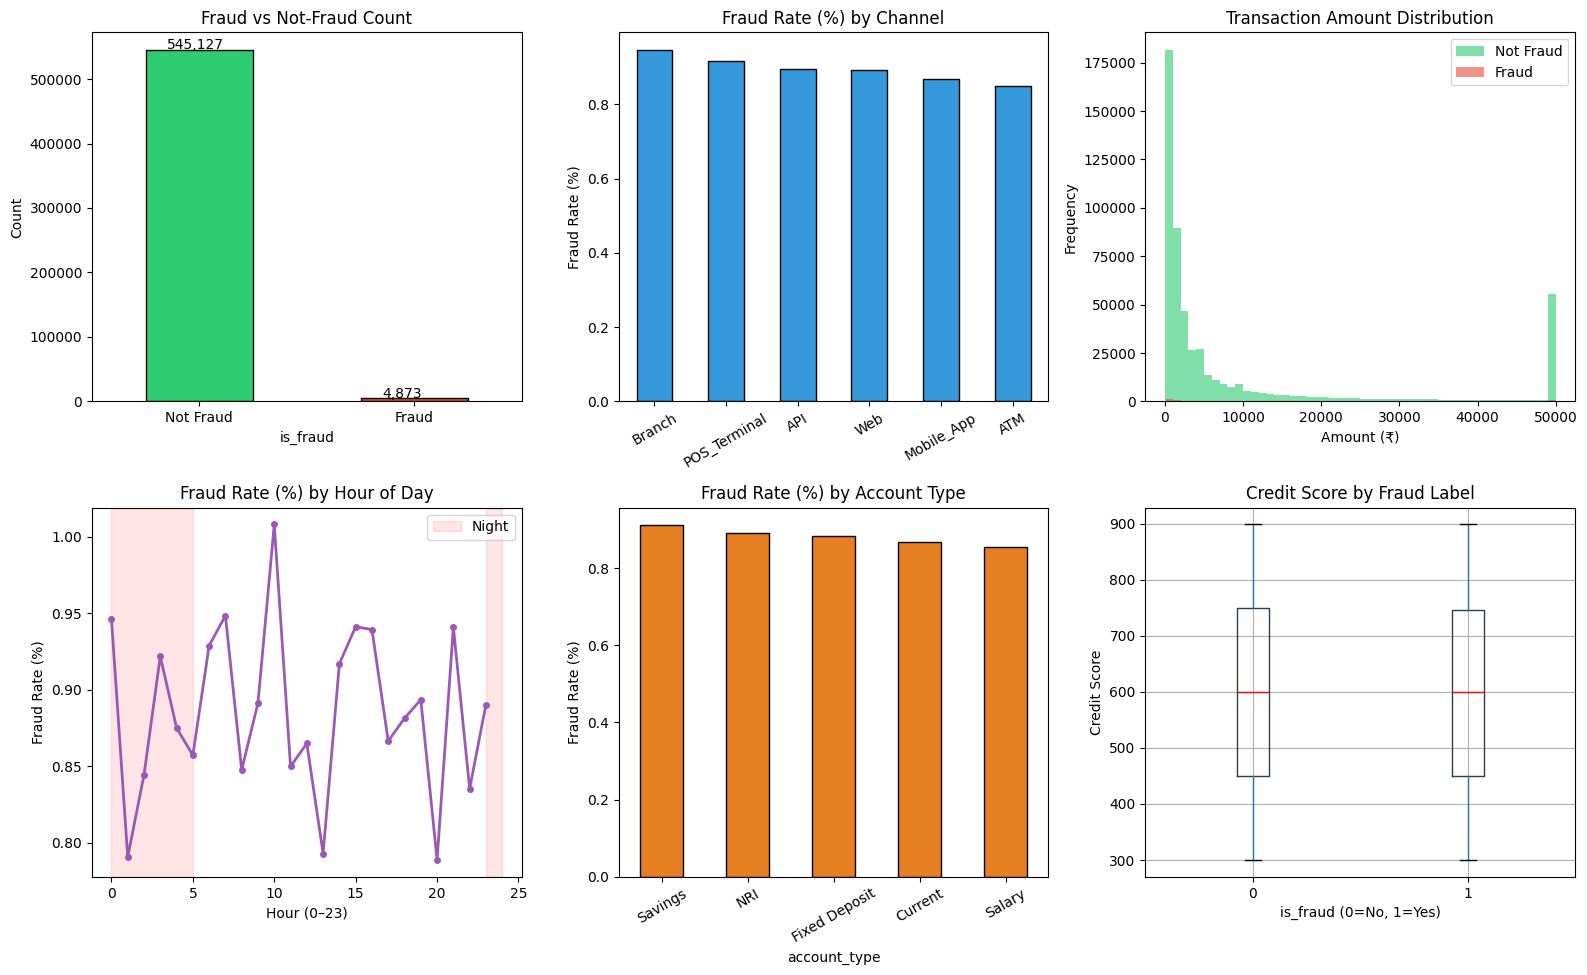

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(' Exploratory Data Analysis — Indian Banking Transactions',
             fontsize=14, fontweight='bold')

# --- Plot 1: Fraud vs Not-Fraud ---
ax = axes[0, 0]
fraud_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='black')
ax.set_title('Fraud vs Not-Fraud Count')
ax.set_xlabel('is_fraud')
ax.set_ylabel('Count')
ax.set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+0.1, p.get_height()+1000))

# --- Plot 2: Fraud by Transaction Channel ---


ax = axes[0, 1]
channel_fraud = df.groupby('channel')['is_fraud'].mean().sort_values(ascending=False) * 100
channel_fraud.plot(kind='bar', color='#3498db', ax=ax, edgecolor='black')
ax.set_title('Fraud Rate (%) by Channel')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)


# --- Plot 3: Transaction Amount Distribution ---
ax = axes[0, 2]
df[df['is_fraud']==0]['transaction_amount'].clip(upper=50000).plot(
    kind='hist', bins=50, alpha=0.6, color='#2ecc71', label='Not Fraud', ax=ax)
df[df['is_fraud']==1]['transaction_amount'].clip(upper=50000).plot(
    kind='hist', bins=50, alpha=0.6, color='#e74c3c', label='Fraud', ax=ax)
ax.set_title('Transaction Amount Distribution')
ax.set_xlabel('Amount (₹)')
ax.legend()

# --- Plot 4: Fraud by Hour ---
ax = axes[1, 0]
hour_fraud = df.groupby('transaction_hour')['is_fraud'].mean() * 100
ax.plot(hour_fraud.index, hour_fraud.values, color='#9b59b6', linewidth=2, marker='o', markersize=4)
ax.set_title('Fraud Rate (%) by Hour of Day')
ax.set_xlabel('Hour (0–23)')
ax.set_ylabel('Fraud Rate (%)')
ax.axvspan(23, 24, alpha=0.1, color='red', label='Night')
ax.axvspan(0, 5, alpha=0.1, color='red')
ax.legend()


# --- Plot 5: Fraud by Account Type ---
ax = axes[1, 1]
acc_fraud = df.groupby('account_type')['is_fraud'].mean().sort_values(ascending=False) * 100
acc_fraud.plot(kind='bar', color='#e67e22', ax=ax, edgecolor='black')
ax.set_title('Fraud Rate (%) by Account Type')
ax.set_ylabel('Fraud Rate (%)')
ax.tick_params(axis='x', rotation=30)

# --- Plot 6: Credit Score vs Fraud ---
ax = axes[1, 2]
df.boxplot(column='credit_score', by='is_fraud', ax=ax,
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red'))
ax.set_title('Credit Score by Fraud Label')
ax.set_xlabel('is_fraud (0=No, 1=Yes)')
ax.set_ylabel('Credit Score')
plt.suptitle('')

plt.tight_layout()
plt.show()


In [52]:
drop_cols = ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time']


feature_cols = [c for c in df.columns if c not in drop_cols + ['is_fraud']]
target_col = 'is_fraud'

print(f" Features used ({len(feature_cols)}):")
print(feature_cols)

 Features used (17):
['account_type', 'transaction_type', 'transaction_amount', 'transaction_direction', 'account_balance', 'merchant_category', 'state', 'credit_score', 'has_loan', 'loan_type', 'emi_amount', 'transaction_status', 'channel', 'kyc_status', 'transaction_hour', 'is_night', 'is_high_amount']


In [53]:
df_ml = df[feature_cols + [target_col]].copy()

le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print(f" Encoded {len(cat_cols)} categorical columns: {cat_cols}")

 Encoded 9 categorical columns: ['account_type', 'transaction_type', 'transaction_direction', 'merchant_category', 'state', 'loan_type', 'transaction_status', 'channel', 'kyc_status']


In [54]:
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training set:  {X_train.shape[0]:,} rows")
print(f" Test set:      {X_test.shape[0]:,} rows")
print()
print(f"Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

 Training set:  440,000 rows
 Test set:      110,000 rows

Fraud in train: 3,898 (0.89%)
Fraud in test : 975  (0.89%)


In [57]:
smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f" After SMOTE:")
print(f"   Not Fraud: {(y_train_sm==0).sum():,}")
print(f"   Fraud:     {(y_train_sm==1).sum():,}")

 After SMOTE:
   Not Fraud: 436,102
   Fraud:     43,610


In [58]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, y_train_sm)
print(" Model training complete!")

 Model training complete!


In [59]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(" Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

print(f" ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("   (Score close to 1.0 = excellent model!)")

 Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.85      0.91    109025
       Fraud       0.01      0.18      0.02       975

    accuracy                           0.84    110000
   macro avg       0.50      0.51      0.47    110000
weighted avg       0.98      0.84      0.91    110000

 ROC-AUC Score: 0.5236
   (Score close to 1.0 = excellent model!)


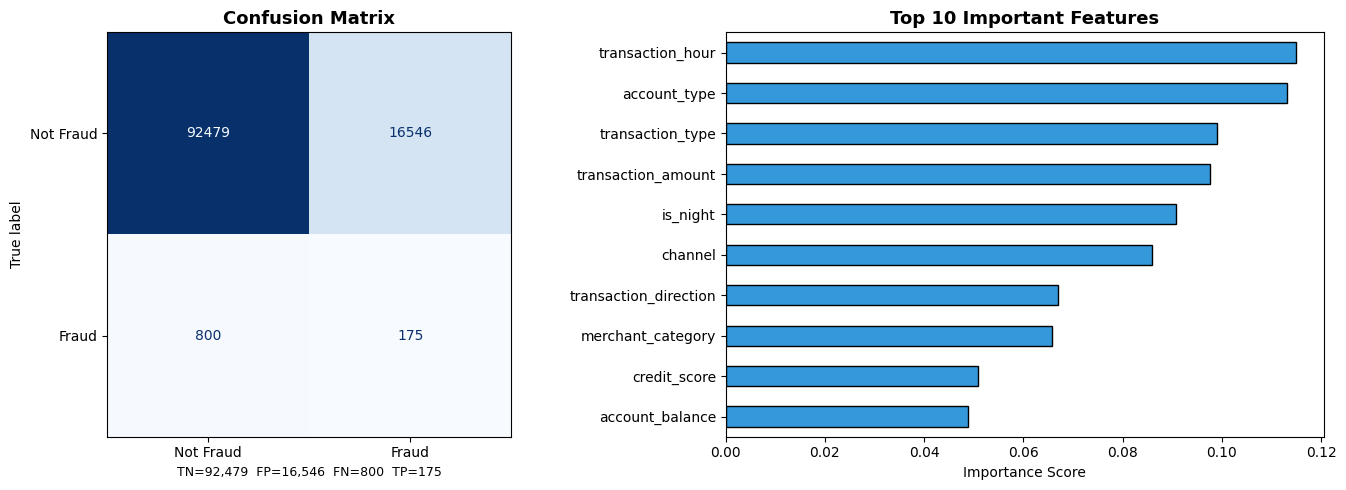


 Tip: Features at the top matter the MOST for predicting fraud!


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}", fontsize=9)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)
top10.sort_values().plot(kind='barh', color='#3498db', ax=axes[1], edgecolor='black')
axes[1].set_title('Top 10 Important Features', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print()
print(" Tip: Features at the top matter the MOST for predicting fraud!")

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob)
}

print("=" * 40)
print("      MODEL PERFORMANCE SUMMARY")
print("=" * 40)
for metric, value in metrics.items():
    bar = '█' * int(value * 20)
    print(f"  {metric:<12}: {value:.4f}  {bar}")
print("=" * 40)

      MODEL PERFORMANCE SUMMARY
  Accuracy    : 0.8423  ████████████████
  Precision   : 0.0105  
  Recall      : 0.1795  ███
  F1-Score    : 0.0198  
  ROC-AUC     : 0.5236  ██████████


# **Starter EDA**


---

Explore patterns, visualize distributions, and build a baseline fraud detection model

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('/content/drive/MyDrive/indian_banking_transactions.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (550000, 20)


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,15:28,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,NaN,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,03:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,NaN,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,18:03,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,08:03,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,14:23,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,NaN,0.00,Success,API,Verified,0,14


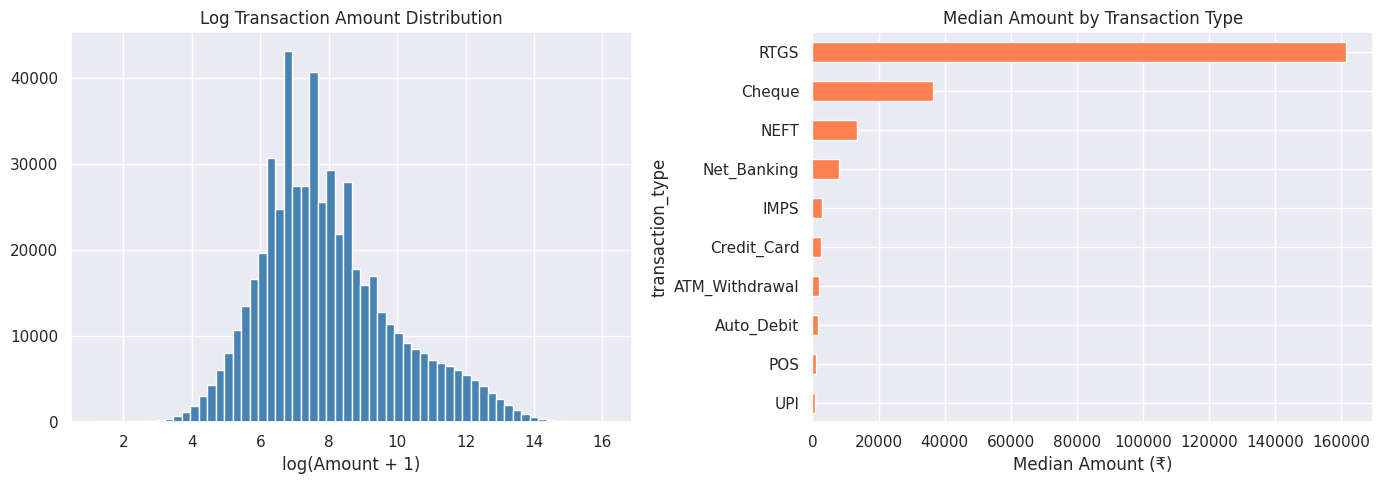

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(df['transaction_amount']), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Log Transaction Amount Distribution')
axes[0].set_xlabel('log(Amount + 1)')

df.groupby('transaction_type')['transaction_amount'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Median Amount by Transaction Type')
axes[1].set_xlabel('Median Amount (₹)')

plt.tight_layout()
plt.show()

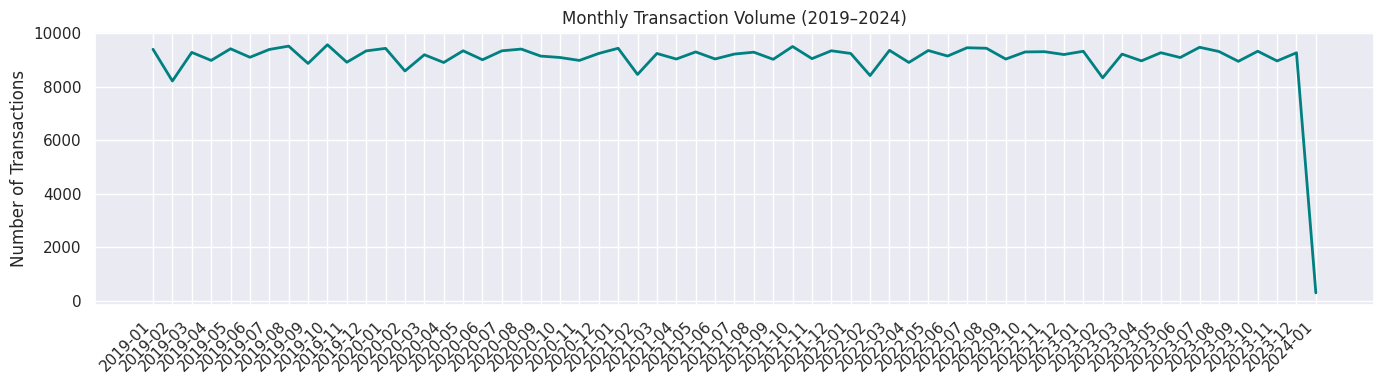

In [64]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly = df.groupby('year_month').size().reset_index(name='count')
monthly['year_month'] = monthly['year_month'].astype(str)

plt.figure(figsize=(14, 4))
plt.plot(monthly['year_month'], monthly['count'], color='teal', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Transaction Volume (2019–2024)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

Overall Fraud Rate: 0.886%
Fraud Transactions : 4,873
Legit Transactions : 545,127


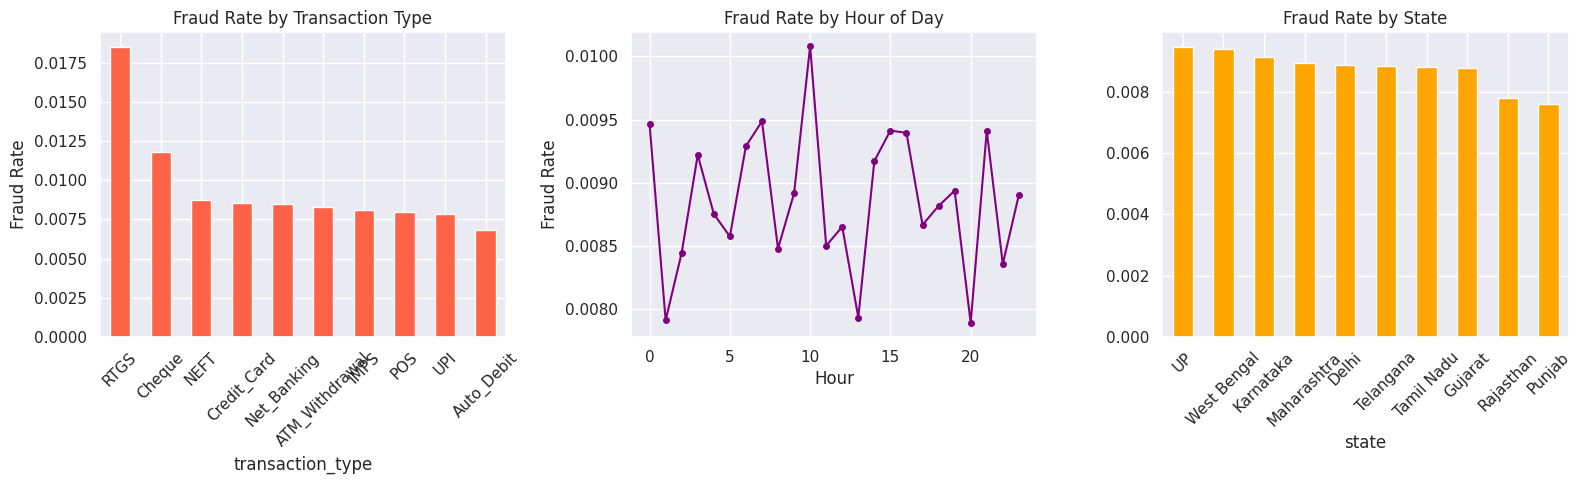

In [68]:
fraud_rate = df['is_fraud'].mean()
print(f'Overall Fraud Rate: {fraud_rate:.3%}')
print(f'Fraud Transactions : {df["is_fraud"].sum():,}')
print(f'Legit Transactions : {(df["is_fraud"]==0).sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fraud by transaction type
fraud_by_type = df.groupby('transaction_type')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Fraud Rate by Transaction Type')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)


# Fraud by hour
fraud_by_hour = df.groupby('transaction_hour')['is_fraud'].mean()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values, color='purple', marker='o', ms=4)
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')


# Fraud by state
fraud_by_state = df.groupby('state')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_state.plot(kind='bar', ax=axes[2], color='orange')
axes[2].set_title('Fraud Rate by State')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

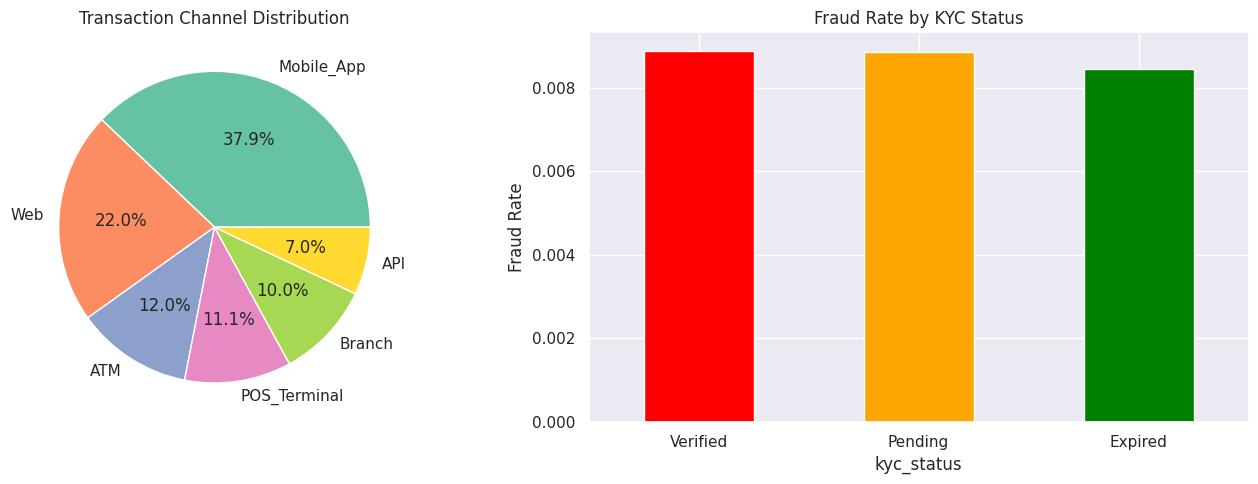

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_counts = df['channel'].value_counts()
axes[0].pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(channel_counts)))
axes[0].set_title('Transaction Channel Distribution')

kyc_fraud = df.groupby('kyc_status')['is_fraud'].mean().sort_values(ascending=False)
kyc_fraud.plot(kind='bar', ax=axes[1], color=['red','orange','green'])
axes[1].set_title('Fraud Rate by KYC Status')
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Baseline Fraud Detection Model**

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

df_model = df.copy()
cat_cols = ['account_type','transaction_type','transaction_direction',
            'merchant_category','state','channel','kyc_status','loan_type']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

features = ['transaction_amount','account_balance','credit_score','transaction_hour',
            'has_loan','emi_amount','account_type','transaction_type',
            'transaction_direction','merchant_category','state','channel','kyc_status']

X = df_model[features]
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    109025
           1       0.00      0.00      0.00       975

    accuracy                           0.99    110000
   macro avg       0.50      0.50      0.50    110000
weighted avg       0.98      0.99      0.99    110000

ROC-AUC Score: 0.5292


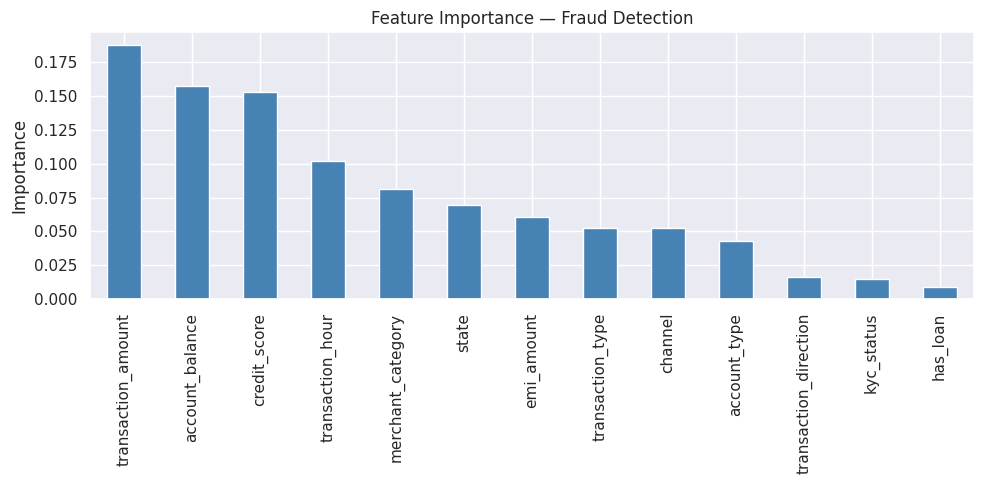

In [72]:
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Fraud Detection')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()